In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sr_ci_filter import apply_sr_ci_filters

# Improved Isopleths filtering configuration
# Keep disabled until the Synoptic series is rebuilt with UTC-aligned timestamps.
APPLY_SR_CI_FILTERS = False
SR_THRESHOLD = 710  # W/m^2; retain SR_Synoptic >= this value
CLEARING_INDEX_THRESHOLD = 1000  # Retain clearing index <= this value
TARGET_AIRSHED = "Northern Wasatch Front"

# Load monitor-resolved Hawthorne chemistry after explicit POC selection.
AQS_ANALYSIS_FILE = (
    "data/downloads/Hawthorne/20240101_20260728_20260729T004631Z/"
    "aqs_analysis_ready.parquet"
)
data = pd.read_parquet(AQS_ANALYSIS_FILE)
data = data.set_index("datetime_local_standard").sort_index()

# Load the UV data and convert index to datetime
UVdata = pd.read_csv("data/UV Data/UV Data All Time HW LP RB.csv", index_col=0)
UVdata = UVdata[['HW']]
UVdata.index = pd.to_datetime(UVdata.index, format='mixed', errors='coerce')

# Merge the dataframes by their date indices
data = data.merge(UVdata, left_index=True, right_index=True)

data.rename(columns={'HW': 'UV'}, inplace=True)

# The Parquet input has already applied row-level MDL and qualifier rules.
data['UV'] = data['UV'].where(data['UV'] > 10)

# Only require variables used by the ratio; audit columns may remain missing.
required_measurements = ['UV', 'NO', 'NO2', 'O3', 'Temp']
data.dropna(subset=required_measurements, inplace=True)

# Only July data at zenith=0
data = data[data.index.month == 5]
data = data[data.index.year == 2025]
# data = data[data.index.hour == 11]

data = apply_sr_ci_filters(
    data,
    enabled=APPLY_SR_CI_FILTERS,
    sr_threshold=SR_THRESHOLD,
    clearing_index_threshold=CLEARING_INDEX_THRESHOLD,
    target_airshed=TARGET_AIRSHED,
)
data.head()



,datetime_utc,NO,NO_raw,NO_below_mdl,NO_quality_flagged,NO_qualifier,NO_detection_limit,NO_poc,NO_method_code,NO2,...,Temp,Temp_raw,Temp_below_mdl,Temp_quality_flagged,Temp_qualifier,Temp_detection_limit,Temp_poc,Temp_method_code,core_chemistry_complete,UV
2025-05-16 13:00:00,2025-05-16 20:00:00+00:00,0.1,0.1,False,False,<NA>,0.05,2,699,1.9,...,62.0,62.0,False,False,<NA>,-60.0,1,040,True,22.0
2025-05-16 14:00:00,2025-05-16 21:00:00+00:00,0.1,0.1,False,False,<NA>,0.05,2,699,2.3,...,62.0,62.0,False,False,<NA>,-60.0,1,040,True,12.0
2025-05-16 15:00:00,2025-05-16 22:00:00+00:00,0.2,0.2,False,False,<NA>,0.05,2,699,2.4,...,64.0,64.0,False,False,<NA>,-60.0,1,040,True,16.0
2025-05-17 08:00:00,2025-05-17 15:00:00+00:00,0.2,0.2,False,False,<NA>,0.05,2,699,1.9,...,62.0,62.0,False,False,<NA>,-60.0,1,040,True,13.0
2025-05-17 09:00:00,2025-05-17 16:00:00+00:00,0.7,0.7,False,False,<NA>,0.05,2,699,3.1,...,64.0,64.0,False,False,<NA>,-60.0,1,040,True,15.0


## Calculating K
- Convert Temp to K
- Calculate K

In [2]:
# Coversion
data['Temp[K]'] = (data['Temp'] - 32) * 5/9 + 273.15

# K calc
A = 3.0e-12
EoR = 1500
data['K'] = A * np.exp(-EoR / (data['Temp[K]'])) #This unit seems to be cm**3 Molecules**-1 s**-1

f298 = 1.07
g = 130
data['f_T'] = f298 * np.exp(g * (1/data['Temp[K]'] - 1/298.0))


## Calculating J

In [3]:
C=7.784e-5 #7.784e-5
sensor_area = 2.84 #cm^2
data['J']=C*data['UV']/sensor_area*10


# Change concentration units
- Ozone ppm -> ppb -> ppbv
- NO ppb -> ppbv
- NOx ppb -> ppbv

In [4]:
# Ideal gas number density (molecules/cm^3)
kB = 1.380649e-23  # J/K
P = 87000         # Pa
T = data['Temp[K]']

n_air = (P / (kB * T)) / 1e6  # molecules/cm^3


# Convert mixing ratios to molecules/cm^3
data['O3_mol_per_cm3']  = data['O3']  * 1e-6 * n_air   # ppm -> molecules/cm^3
data['NO_mol_per_cm3']  = data['NO']  * 1e-9 * n_air   # ppb -> molecules/cm^3
data['NO2_mol_per_cm3'] = data['NO2'] * 1e-9 * n_air   # ppb -> molecules/cm^3

# data['O3_mol_per_cm3'] = data['O3'] * 1000 * 2.46E10

# data['NO_mol_per_cm3'] = data['NO'] * 2.46E10

# data['NO2_mol_per_cm3'] = data['NO2'] * 2.46E10



Series([], Name: LR, dtype: Float64)


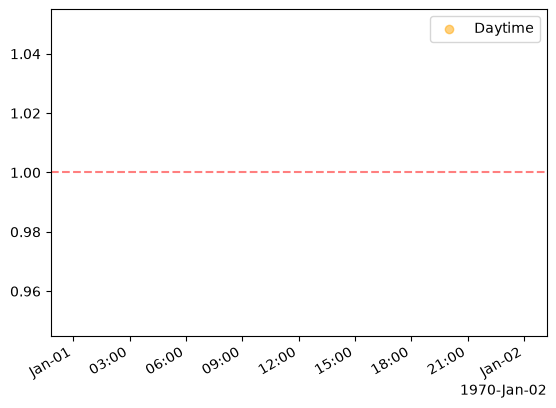

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

data['LR'] = (data['J']*data['NO2_mol_per_cm3'])/(data['K']*data['O3_mol_per_cm3']*data['NO_mol_per_cm3'])
# data['LR'] = data['LR'].apply(lambda x: x if x >= -40 else np.nan)
# data['LR'] = data['LR'].apply(lambda x: x if x <= 40 else np.nan)
#data['LR'] = data['LR'].apply(lambda x: np.nan if x == 0 else x)

# data['LR'] = data['LR'].apply(lambda x: np.log(x))
data.dropna(inplace=True)
print(data['LR'])
# data.to_csv('data/Hawthorne/Leighton_Relationship_HW.csv')

fig, ax = plt.subplots()

# daytime = data[data['UV'] > 5]
# nighttime = data[data['UV'] <= 5]
daytime = data.between_time('09:00', '16:00')
nighttime = data.between_time('16:00', '09:00')

ax.scatter(daytime.index, daytime['LR'], c='orange', alpha=0.5, label='Daytime')
#ax.scatter(nighttime.index, nighttime['LR'], c='blue', alpha=0.5, label='Nighttime')

ax.legend()
ax.axhline(y=1, color='r', linestyle='--', alpha=0.5)






ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

fig.autofmt_xdate()


# Daytime Histogram 

The daytime median LR is 0.37754233748096266
The 10th percentile is 0.19284064347042001 and the 90th percentile is 1.3523326218528924


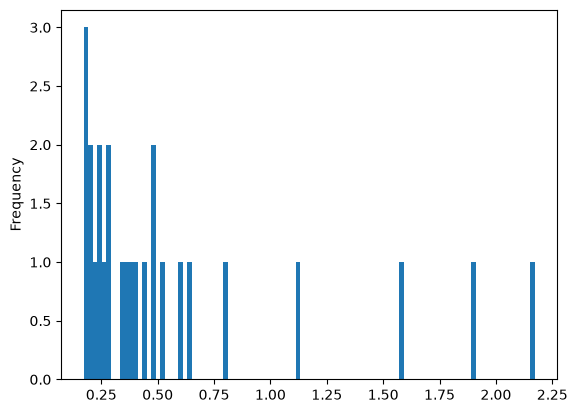

In [21]:
daytime['LR'].plot(kind='hist', bins=100)
median_LR = daytime['LR'].median()
print(f"The daytime median LR is {median_LR}")
print(f"The 10th percentile is {daytime["LR"].quantile(0.1)} and the 90th percentile is {daytime["LR"].quantile(0.9)}")

# Nighttime Histogram

The nightime median LR is 0.36817217103724204


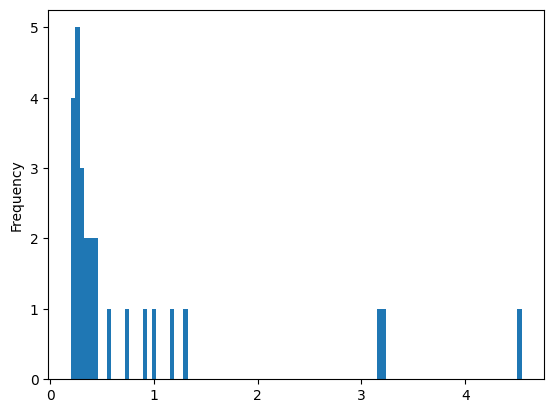

In [40]:
nighttime['LR'].plot(kind='hist', bins=100)
median_LR = nighttime['LR'].median()
print(f"The nightime median LR is {median_LR}")

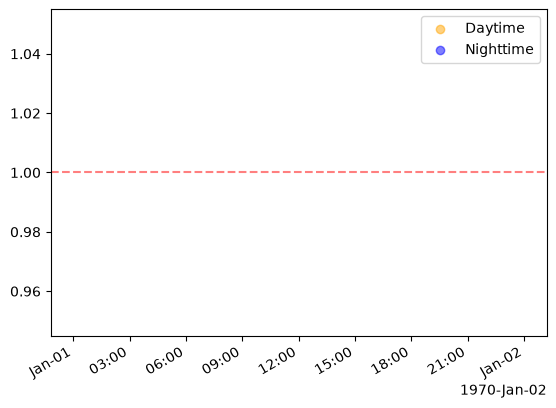

In [44]:
summer_2024 = data.loc['2023-05':'2023-09']
daytime = summer_2024.between_time('09:00', '16:00')
nighttime = summer_2024.between_time('16:00', '09:00')

fig, ax = plt.subplots()
ax.scatter(daytime.index, daytime['LR'], c='orange', alpha=0.5, label='Daytime')
ax.scatter(nighttime.index, nighttime['LR'], c='blue', alpha=0.5, label='Nighttime')
ax.legend()
ax.axhline(y=1, color='r', linestyle='--', alpha=0.5)
# data['LR'].plot(kind='hist', bins=100)





ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

fig.autofmt_xdate()

# Uncertainty 

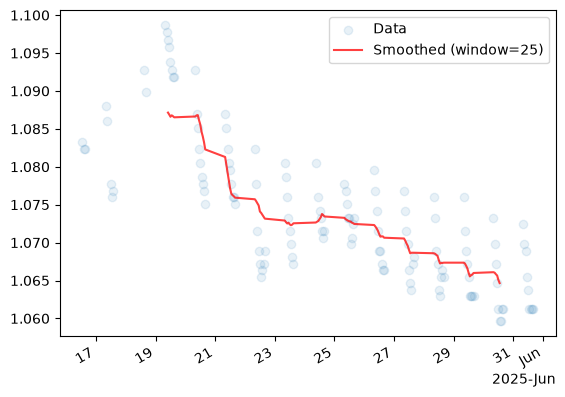

In [45]:
fig, ax = plt.subplots()
ax.scatter(data.index, data['f_T'], alpha=0.1, label='Data')

# Add smoothing line
window_size = 25
smoothed = data['f_T'].rolling(window=window_size, center=True).mean()
ax.plot(data.index, smoothed, color='red', label=f'Smoothed (window={window_size})', alpha=0.75)

ax.legend()

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

fig.autofmt_xdate()
